In [1]:
import sys
from pathlib import Path

# Let the notebook import our own code from src/
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import joblib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

from src.training.train import load_split, make_model, MODELS_DIR
from src.training.preprocess import NUMERIC_FEATURES
from src.training.evaluate import evaluate

X_train, y_train = load_split("train")
X_val, y_val = load_split("val")
xgb = joblib.load(MODELS_DIR / "xgboost.joblib")
print("Loaded:", X_train.shape, X_val.shape)

Loaded: (924850, 15) (371825, 15)


In [2]:
scores = xgb.predict_proba(X_val)[:, 1]
tn, fp, fn, tp = confusion_matrix(y_val, scores >= 0.5).ravel()

print(f"Frauds caught (TP):       {tp:>8,}")
print(f"Frauds missed (FN):       {fn:>8,}")
print(f"False alarms (FP):        {fp:>8,}  -> {fp / (fp + tn):.3%} of legit customers")
print(f"Correctly approved (TN):  {tn:>8,}")

Frauds caught (TP):          2,225
Frauds missed (FN):             61
False alarms (FP):             480  -> 0.130% of legit customers
Correctly approved (TN):   369,059


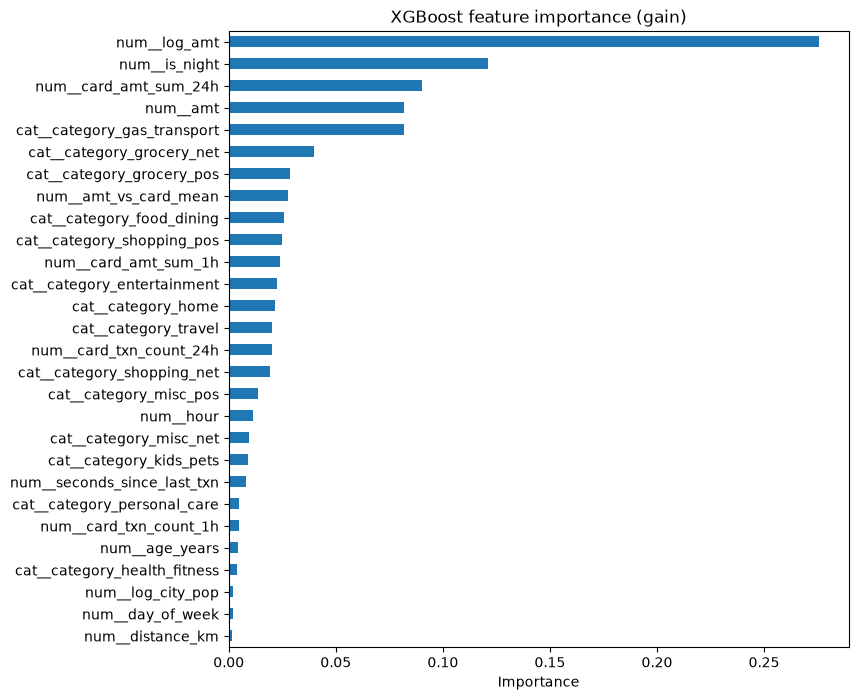

In [3]:
names = xgb["preprocess"].get_feature_names_out()
importance = pd.Series(xgb["model"].feature_importances_, index=names).sort_values()

ax = importance.plot(kind="barh", figsize=(8, 8))
ax.set_title("XGBoost feature importance (gain)")
ax.set_xlabel("Importance")
plt.show()

In [4]:
CARD_HISTORY = [f for f in NUMERIC_FEATURES if f.startswith(("card_", "seconds_", "amt_vs"))]
AMOUNT = ["amt", "log_amt", "card_amt_sum_1h", "card_amt_sum_24h", "amt_vs_card_mean"]

experiments = {
    "all features": NUMERIC_FEATURES,
    "no card history": [f for f in NUMERIC_FEATURES if f not in CARD_HISTORY],
    "no amount features": [f for f in NUMERIC_FEATURES if f not in AMOUNT],
}

rows = {}
for name, numeric in experiments.items():
    print("Training:", name)
    model = make_model("xgboost", y_train, numeric=numeric).fit(X_train, y_train)
    m = evaluate(y_val, model.predict_proba(X_val)[:, 1])
    rows[name] = {k: m[k] for k in ["pr_auc", "recall_at_1pct_fpr", "precision", "recall"]}

ablation = pd.DataFrame(rows).T.round(4)
ablation

Training: all features
Training: no card history
Training: no amount features


,pr_auc,recall_at_1pct_fpr,precision,recall
all features,0.9835,0.9961,0.8226,0.9733
no card history,0.8947,0.9580,0.4442,0.9440
no amount features,0.3987,0.4742,0.0835,0.7060


## Findings

**Baseline comparison (validation set):** XGBoost PR-AUC 0.9835 vs logistic regression 0.4315
vs dummy 0.0061 (= base rate). Logistic regression reaches ROC-AUC 0.99 but only 14% precision,
confirming that ROC-AUC is misleading under heavy class imbalance.

**Error profile at threshold 0.5:** 2,225 frauds caught, 61 missed (recall 97.3%);
480 false alarms, i.e. 0.13% of legitimate customers.

**Feature importance** matches the EDA: `log_amt`, `is_night`, `card_amt_sum_24h`, `amt`
and merchant category dominate. `amt` and `log_amt` carry the same information, so their
importance is split between them.

**Ablation study:**

| Experiment | PR-AUC | Precision | Recall |
|---|---|---|---|
| All features | 0.9835 | 0.82 | 0.97 |
| No card-history features | 0.8947 | 0.44 | 0.94 |
| No amount features | 0.3987 | 0.08 | 0.71 |

- Removing real-time card-history features roughly halves precision: about **5.6x more false
  alarms** (~2,700 vs 480) at similar recall. **This justifies the streaming architecture.**
- Amount features are the strongest signal. The two groups overlap slightly
  (`card_amt_sum_*`, `amt_vs_card_mean` belong to both).

**Credibility:** no sign of leakage (leakage unit test passes, model relies on EDA-consistent
signals, ablations degrade as expected). However, fraud patterns in this simulated dataset are
unusually clean, so these scores are likely **optimistic** compared with real bank data.

In [5]:
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import time

strategies = {
    "no handling": dict(class_weighting=False),
    "class weights": dict(class_weighting=True),
    "undersampling": dict(
        class_weighting=False,
        samplers=[RandomUnderSampler(sampling_strategy=0.1, random_state=42)],
    ),
    "SMOTE": dict(
        class_weighting=False,
        samplers=[SMOTE(sampling_strategy=0.1, random_state=42)],
    ),
    "undersampling + SMOTE-Tomek": dict(
        class_weighting=False,
        samplers=[
            RandomUnderSampler(sampling_strategy=0.1, random_state=42),
            SMOTETomek(sampling_strategy=0.3, random_state=42),
        ],
    ),
}

rows = {}
for name, options in strategies.items():
    print("Training:", name)
    start = time.perf_counter()
    model = make_model("xgboost", y_train, **options).fit(X_train, y_train)
    m = evaluate(y_val, model.predict_proba(X_val)[:, 1])
    rows[name] = {k: m[k] for k in ["pr_auc", "recall_at_1pct_fpr", "precision", "recall"]}
    rows[name]["train_seconds"] = time.perf_counter() - start

imbalance = pd.DataFrame(rows).T.round(4)
imbalance

Training: no handling
Training: class weights
Training: undersampling
Training: SMOTE
Training: undersampling + SMOTE-Tomek


,pr_auc,recall_at_1pct_fpr,precision,recall,train_seconds
no handling,0.9814,0.9956,0.9631,0.9143,60.0508
class weights,0.9835,0.9961,0.8226,0.9733,54.5893
undersampling,0.9804,0.9943,0.7932,0.9733,7.3367
SMOTE,0.9853,0.9956,0.9573,0.9418,61.0625
undersampling + SMOTE-Tomek,0.9799,0.9952,0.7558,0.9764,35.1428
